<a href="https://colab.research.google.com/github/sahilchettri-data/esg_risk_analysis/blob/main/S%26P500ESGRiskAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# S&P 500 ESG Risk Analysis

## Overview
This project analyzes ESG (Environmental, Social, and Governance) risk ratings for S&P 500 companies.
The dataset contains 503 companies across 11 sectors with individual E, S, and G risk scores sourced from Yahoo Finance via Kaggle.

## Objectives
- Identify which sectors carry the highest and lowest ESG risk
- Break down risk by Environmental, Social, and Governance dimensions
- Visualize patterns across sectors for sustainability-focused investment insight

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("pritish509/s-and-p-500-esg-risk-ratings")

print("Path to dataset files:", path)

100%|██████████| 247k/247k [00:00<00:00, 57.8MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/pritish509/s-and-p-500-esg-risk-ratings/versions/2


In [2]:
import pandas as pd
import os

files = os.listdir(path)
print(files)

['SP 500 ESG Risk Ratings.csv']


## 1. Data Loading & Cleaning
The dataset was sourced from Kaggle (S&P 500 ESG Risk Ratings).
After loading, 73 rows with missing ESG scores were dropped, leaving 430 companies for analysis.

In [12]:
df = pd.read_csv(path + '/SP 500 ESG Risk Ratings.csv')

print(df.head())
print(df.columns)
df = df.dropna(subset=['Total ESG Risk score'])
print(df.shape)
print(df.isnull().sum())



  Symbol                      Name  \
0   ENPH      Enphase Energy, Inc.   
1    EMN  Eastman Chemical Company   
2    DPZ       Domino's Pizza Inc.   
3    DAY            Dayforce, Inc.   
4    DVA               Davita Inc.   

                                             Address             Sector  \
0  47281 Bayside Parkway\nFremont, CA 94538\nUnit...         Technology   
1  200 South Wilcox Drive\nKingsport, TN 37662\nU...    Basic Materials   
2  30 Frank Lloyd Wright Drive\nAnn Arbor, MI 481...  Consumer Cyclical   
3  3311 East Old Shakopee Road\nMinneapolis, MN 5...         Technology   
4  2000 16th Street\nDenver, CO 80202\nUnited States         Healthcare   

                  Industry Full Time Employees  \
0                    Solar               3,157   
1      Specialty Chemicals              14,000   
2              Restaurants               6,500   
3   Software - Application               9,084   
4  Medical Care Facilities              70,000   

                   

## 2. Sector-Level Analysis
Grouping companies by sector to identify average ESG risk scores across Environmental, Social, and Governance dimensions.

In [ ]:
avgsecesg=df.groupby('Sector')['Total ESG Risk score'].mean()
highsec=avgsecesg.idxmax()
lowsec=avgsecesg.idxmin()
print(avgsecesg.sort_values())
print(f"Sector with the Lowest Total ESG Risk Score is {lowsec} sector while sector with the Highest Total ESG Risk Score is {highsec} sector.")

## 3. Visualizations

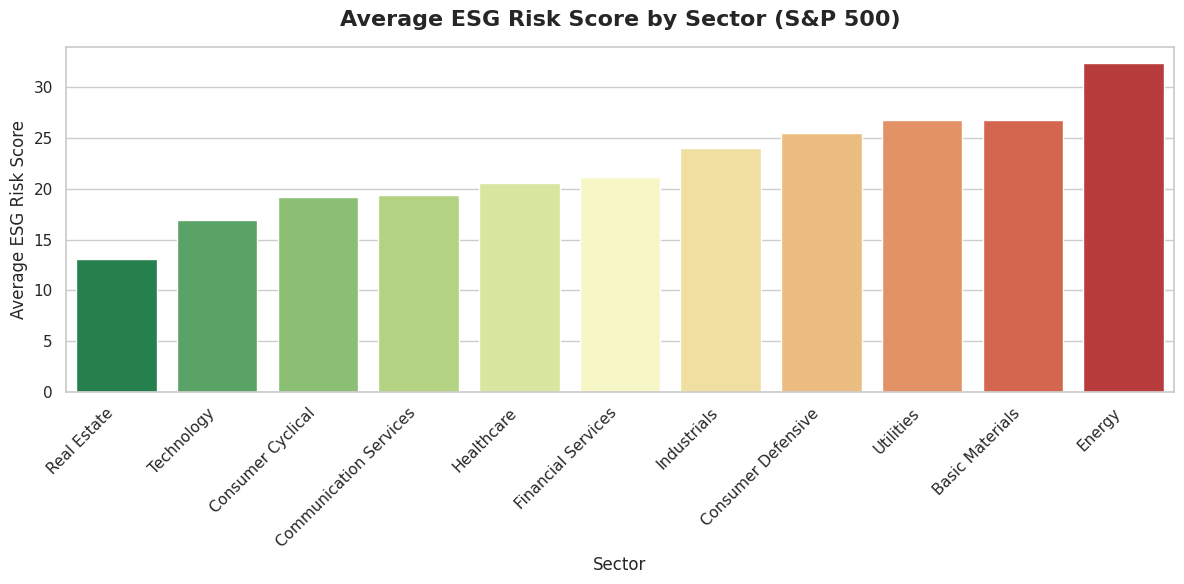

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

avgsecesg_df = avgsecesg.reset_index().sort_values('Total ESG Risk score')

sns.set_theme(style='whitegrid')
plt.figure(figsize=(12, 6))

bars = sns.barplot(data=avgsecesg_df, x='Sector', y='Total ESG Risk score',
                   palette='RdYlGn_r', hue='Sector', legend=False)

plt.xticks(rotation=45, ha='right', fontsize=11)
plt.title('Average ESG Risk Score by Sector (S&P 500)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Sector', fontsize=12)
plt.ylabel('Average ESG Risk Score', fontsize=12)
plt.tight_layout()
plt.show()


We can see here that the Real Estate Sector has the lowest average ESG Risk Score, and not surprising that the Energy Sector has the highest.

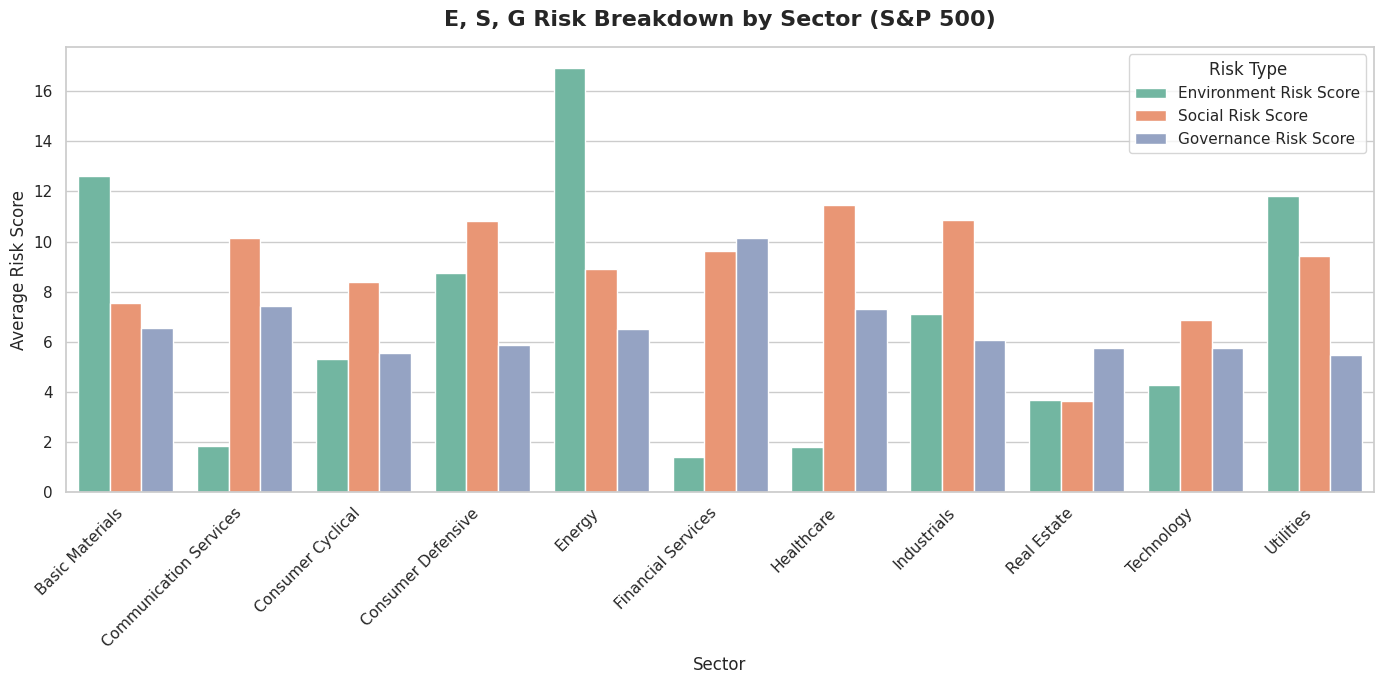

In [6]:
avg_scores = df.groupby('Sector')[['Total ESG Risk score', 'Environment Risk Score', 'Social Risk Score', 'Governance Risk Score']].mean().reset_index()
# print(avg_scores)

melted = avg_scores.melt(id_vars='Sector',
                          value_vars=['Environment Risk Score', 'Social Risk Score', 'Governance Risk Score'],
                          var_name='Risk Type',
                          value_name='Score')
plt.figure(figsize=(14, 7))
sns.barplot(data=melted, x='Sector', y='Score', hue='Risk Type', palette='Set2')
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.title('E, S, G Risk Breakdown by Sector (S&P 500)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Sector', fontsize=12)
plt.ylabel('Average Risk Score', fontsize=12)
plt.tight_layout()
plt.show()

In this bar graph we can see that the Energy Sector is towering in the Environment Risk Sector. Real Estate Sector has a relatively low Risk Scores in all 3 Categories. Communication Services, Financial Services, and Healthcare are all Sectors with pretty low Environmental Risk Score but moderately high Social and Governance Risk Scores.

<Axes: xlabel='Environment Risk Score', ylabel='Total ESG Risk score'>

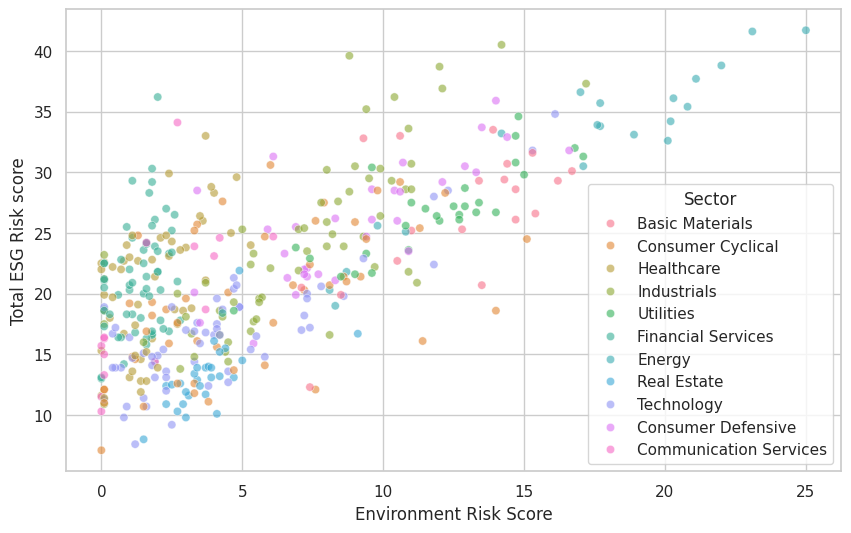

In [11]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Environment Risk Score', y='Total ESG Risk score',
                hue='Sector', alpha=0.6, legend=True)
plt.title('Environment Risk vs Total ESG Risk Score', fontsize=16, fontweight='bold')
plt.xlabel('Environment Risk Score', fontsize=12)
plt.ylabel('Total ESG Risk Score', fontsize=12)
plt.tight_layout()
plt.show()

This scatterplot tells us that Environmental Risk, though an important factor in the overall ESG Risk Score, is not the only deciding factor. We can see that many companies, especially in the Financial Sector have low Environment Risk Score but moderately high Total ESG Risk Score.

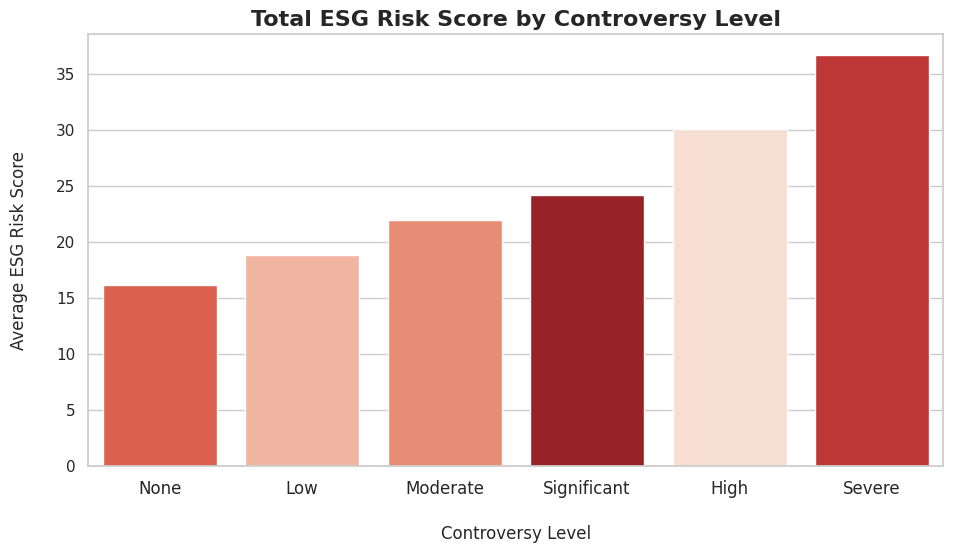

In [39]:
contro=df.groupby('Controversy Level')['Total ESG Risk score'].mean().reset_index()
order=['None Controversy Level', 'Low Controversy Level', 'Moderate Controversy Level', 'Significant Controversy Level', 'High Controversy Level', 'Severe Controversy Level']
plt.figure(figsize=(10, 6))
sns.barplot(data=contro, x='Controversy Level', y='Total ESG Risk score', palette='Reds', hue='Controversy Level', order=order, legend=False)
plt.xlabel('Controversy Level', fontsize=12, labelpad=20)
plt.xticks(ticks=range(len(order)), labels=['None', 'Low', 'Moderate', 'Significant', 'High', 'Severe'], fontsize=12)
plt.ylabel('Average ESG Risk Score', fontsize=12, labelpad=20)
plt.title('Total ESG Risk Score by Controversy Level', fontsize=16, fontweight='bold')
plt.tight_layout(pad=2.0)
plt.show()

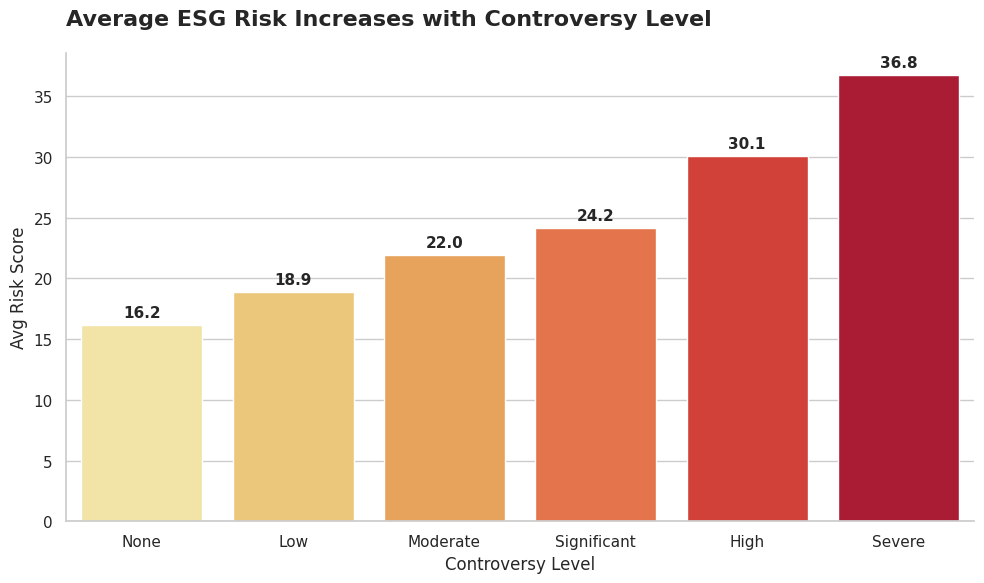

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calculation & Order
contro = df.groupby('Controversy Level')['Total ESG Risk score'].mean().reindex(order).reset_index()

plt.figure(figsize=(10, 6))

# 2. Use a sequential palette to show increasing intensity
ax = sns.barplot(
    data=contro,
    x='Controversy Level',
    y='Total ESG Risk score',
    palette='YlOrRd', # Shows 'heat' increasing
    order=order,
    hue='Controversy Level',
    legend=False
)

# 3. Add exact value labels on top of bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points',
                fontsize=11,
                fontweight='bold')

# 4. Styling
plt.title('Average ESG Risk Increases with Controversy Level', fontsize=16, fontweight='bold', loc='left', pad=20)
plt.ylabel('Avg Risk Score', fontsize=12)
plt.xlabel('Controversy Level', fontsize=12)
plt.xticks(ticks=range(len(order)), labels=['None', 'Low', 'Moderate', 'Significant', 'High', 'Severe'])

# Remove top/right spines for a modern look
sns.despine()
plt.tight_layout()
plt.show()

This barplot shows that Companies that are more controversial have a higher ESG Risk Score. Another noticable point is that Companies with no controversy do not have 0 Risk. This implies that even if the Company is not in the news for the wrong reasons, it can still carry risk to the Environment, Society and the Governance.

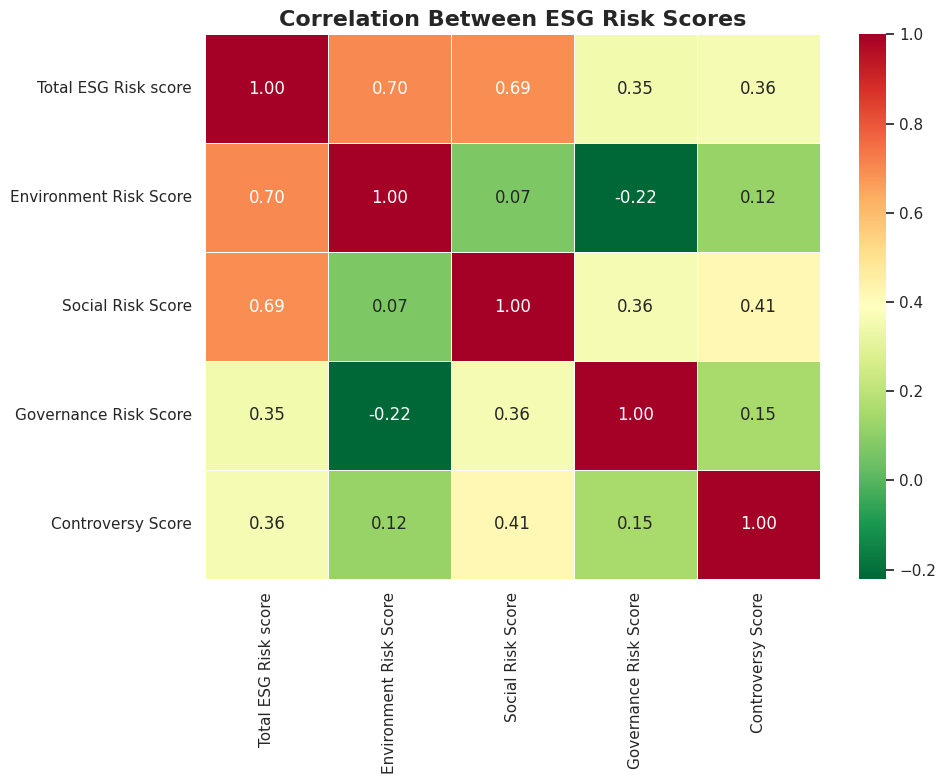

In [47]:
corr_cols=df[['Total ESG Risk score', 'Environment Risk Score', 'Social Risk Score', 'Governance Risk Score', 'Controversy Score']]
correlation = corr_cols.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='RdYlGn_r', linewidths=0.5)
plt.title('Correlation Between ESG Risk Scores', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

The heatmap reveals that Environment Risk and Social Risk are the strongest drivers of Total ESG Risk Score. Governance Risk shows a weaker correlation, suggesting companies can have poor governance independently of their environmental or social performance. This implies that ESG risk is not one-dimensional, i.e, different sectors may be exposed to risk through very different channels.

## 4. Key Insights

- **Energy** sector carries the highest overall ESG risk, driven primarily by Environmental risk scores
- **Real Estate** sector has the lowest overall ESG risk
- **Healthcare** has the highest Social risk score, reflecting labor practices and patient rights concerns
- **Financial Services** has the highest Governance risk, consistent with regulatory and oversight challenges in the industry
- **Controversy correlates with ESG risk** — companies with higher controversy levels carry significantly higher ESG risk scores, though even companies with no controversy carry baseline risk from their industry
- **Environment and Social scores are the strongest drivers** of Total ESG Risk. Governance risk is more independent, suggesting companies can have poor governance without high environmental or social exposure

*Analysis conducted using Python (Pandas, Seaborn, Matplotlib) on S&P 500 ESG Risk Ratings data.*